In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sys, types
import numpy.core.numeric as _nc
_np_core = types.ModuleType("numpy._core")
_np_core.numeric = types.ModuleType("numpy._core.numeric")
_np_core.numeric.__dict__.update(_nc.__dict__)
sys.modules["numpy._core"] = _np_core
sys.modules["numpy._core.numeric"] = _np_core.numeric

# SCP vs Traditional Uncertainty Methods

In [3]:
base_path   = r"C:\Users\MGA5500\Desktop\PROJECT\WW\Data"
calib_seeds = list(range(60, 69))
test_seed   = 69
timesteps   = [25, 160]
nx          = 250
alpha       = 0.10
Z_90        = 1.645
slices      = {'u': slice(0, nx), 'h': slice(nx, 2*nx), 'r': slice(2*nx, 3*nx)}
VARS        = ['u', 'h', 'r']
YLIMS       = {'u': (9.985, 10.015), 'h': (89.90, 90.30), 'r': (-0.005, 0.055)}
YSTEP       = {'u': 0.005, 'h': 0.05, 'r': 0.01}

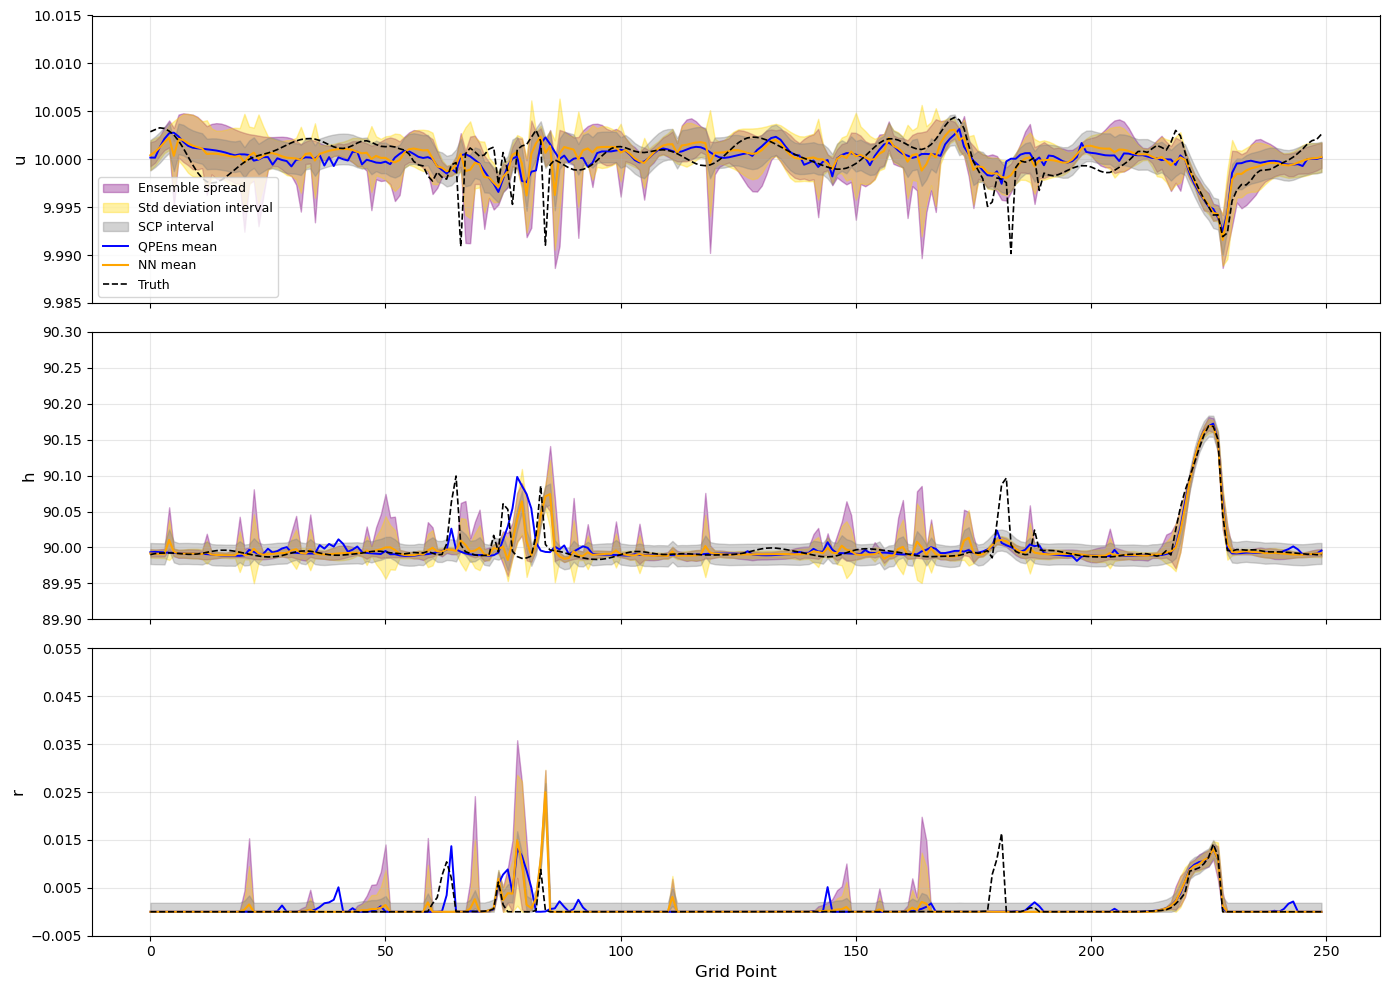

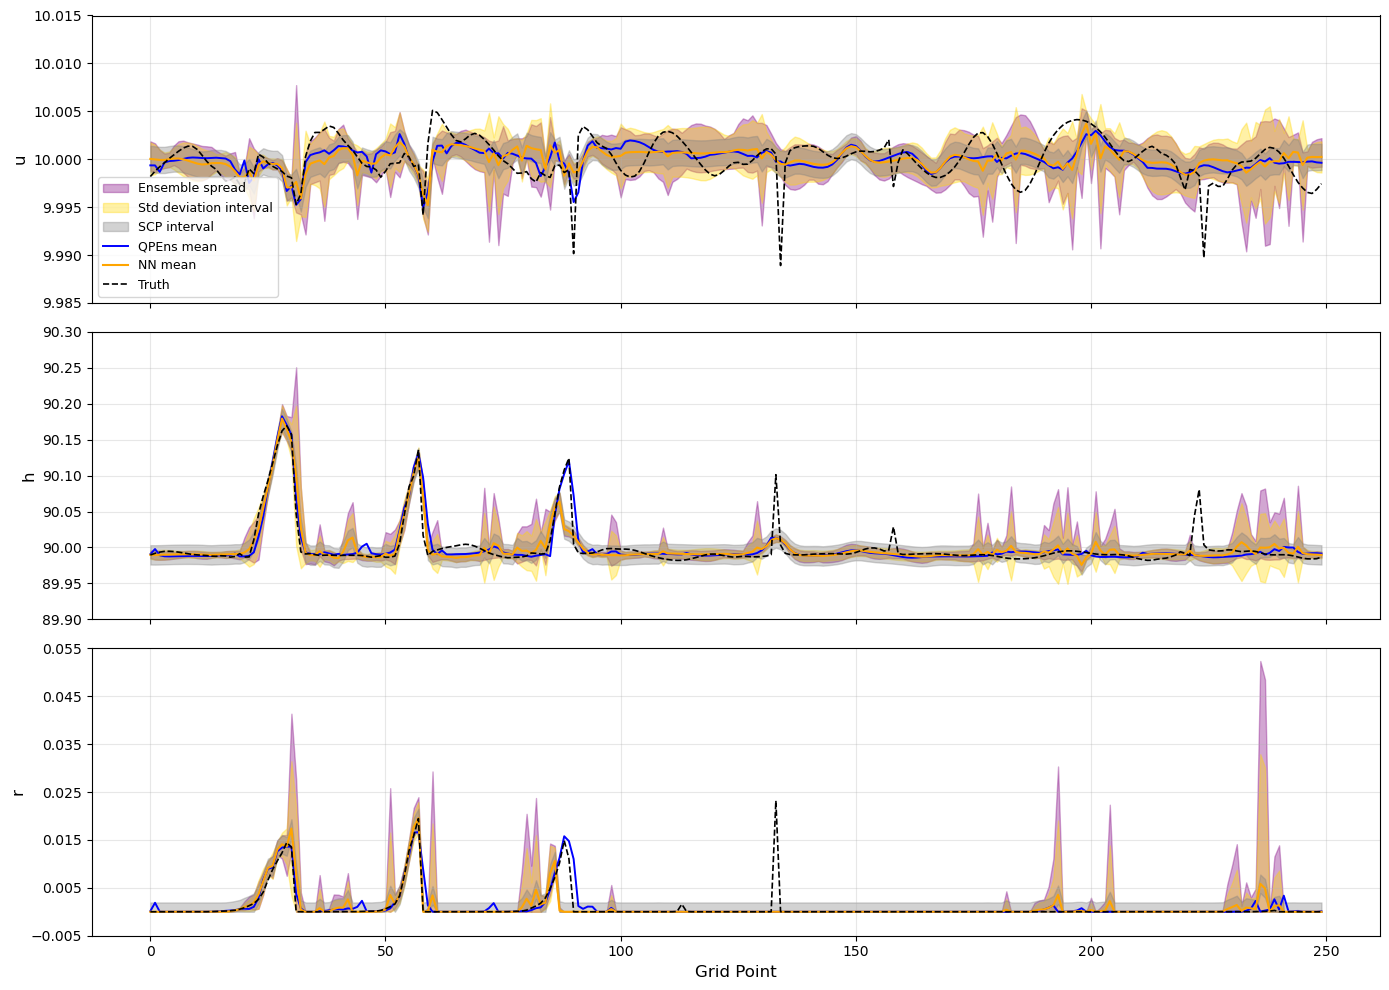

In [4]:
def load_scp_ensemble(seed, t):
    path = os.path.join(base_path, str(seed))
    with open(os.path.join(path, 'NN_data.pkl'), 'rb') as f:
        nn = pickle.load(f)
    with open(os.path.join(path, 'QPEns_data.pkl'), 'rb') as f:
        qpens = pickle.load(f)
    nn_arr    = np.asarray(nn['analysis'][t])
    qpens_arr = np.asarray(qpens['analysis'][t])
    nn_ens    = {v: nn_arr[sl, :].mean(axis=1)    for v, sl in slices.items()}  
    qpens_ens = {v: qpens_arr[sl, :].mean(axis=1) for v, sl in slices.items()} 
    return nn_ens, qpens_ens

def load_scp_plot_data(seed, t):
    path = os.path.join(base_path, str(seed))
    with open(os.path.join(path, 'NN_data.pkl'), 'rb') as f:
        nn = pickle.load(f)
    with open(os.path.join(path, 'QPEns_data.pkl'), 'rb') as f:
        qpens = pickle.load(f)
    with open(os.path.join(path, 'truth_data.pkl'), 'rb') as f:
        truth = pickle.load(f)
    nn_arr    = np.asarray(nn['analysis'][t])       
    qpens_arr = np.asarray(qpens['analysis'][t])    
    truth_arr = np.asarray(truth[t]).squeeze()     
    mean_all  = nn_arr.mean(axis=1)
    std_all   = nn_arr.std(axis=1, ddof=1)
    return {
        'nn_mean' : {v: mean_all[sl]                    for v, sl in slices.items()},
        'nn_lo'   : {v: (mean_all - Z_90*std_all)[sl]   for v, sl in slices.items()},
        'nn_hi'   : {v: (mean_all + Z_90*std_all)[sl]   for v, sl in slices.items()},
        'nn_min'  : {v: nn_arr[sl, :].min(axis=1)       for v, sl in slices.items()},
        'nn_max'  : {v: nn_arr[sl, :].max(axis=1)       for v, sl in slices.items()},
        'q_mean'  : {v: qpens_arr[sl, :].mean(axis=1)   for v, sl in slices.items()},
        'truth'   : {v: truth_arr[sl]                   for v, sl in slices.items()},
    }

def compute_scp_threshold(t):
    nn_cal, qp_cal = {v: [] for v in VARS}, {v: [] for v in VARS}
    for seed in calib_seeds:
        nn_ens, qpens_ens = load_scp_ensemble(seed, t)
        for v in VARS:
            nn_cal[v].append(nn_ens[v])
            qp_cal[v].append(qpens_ens[v])
    thresholds = {}
    for v in VARS:
        nn_stack    = np.stack(nn_cal[v], axis=0)   
        qpens_stack = np.stack(qp_cal[v], axis=0)  
        scores      = np.abs(qpens_stack - nn_stack).ravel()
        N           = scores.size
        qprob       = float(np.ceil((N + 1) * (1 - alpha)) / N)
        thresholds[v] = float(np.quantile(scores, min(qprob, 1.0), method="inverted_cdf"))
    return thresholds

def plot_scp_vs_traditional(t):
    thresholds = compute_scp_threshold(t)
    s = load_scp_plot_data(test_seed, t)
    x = np.arange(nx)
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    for i, v in enumerate(VARS):
        ax         = axes[i]
        nn_line    = s['nn_mean'][v]
        qpens_line = s['q_mean'][v]
        truth_line = s['truth'][v]

        cp_lo  = nn_line - thresholds[v]
        cp_hi  = nn_line + thresholds[v]
        std_lo = s['nn_lo'][v]
        std_hi = s['nn_hi'][v]
        min_l  = s['nn_min'][v]
        max_l  = s['nn_max'][v]

        if v == 'r':
            cp_lo  = np.maximum(cp_lo,  0)
            cp_hi  = np.maximum(cp_hi,  0)
            std_lo = np.maximum(std_lo, 0)
            std_hi = np.maximum(std_hi, 0)
            min_l  = np.maximum(min_l,  0)
            max_l  = np.maximum(max_l,  0)

        ax.fill_between(x, min_l,  max_l,  color='purple', alpha=0.35, label='Ensemble spread')
        ax.fill_between(x, std_lo, std_hi, color='gold',   alpha=0.35, label='Std deviation interval')
        ax.fill_between(x, cp_lo,  cp_hi,  color='gray',   alpha=0.35, label='SCP interval')
        ax.plot(x, qpens_line, color='blue',   linewidth=1.4, label='QPEns mean')
        ax.plot(x, nn_line,    color='orange', linewidth=1.5, label='NN mean')
        ax.plot(x, truth_line, color='black',  linewidth=1.2, linestyle='--', label='Truth')
        ax.set_ylabel(v, fontsize=12)
        ax.set_ylim(YLIMS[v])
        ax.set_yticks(np.arange(YLIMS[v][0], YLIMS[v][1]+0.5*YSTEP[v], YSTEP[v]))
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(loc='lower left', fontsize=9, frameon=True)

    axes[-1].set_xlabel("Grid Point", fontsize=12)
    plt.tight_layout()
    plt.show()

for t in timesteps:
    plot_scp_vs_traditional(t)

# NCP vs Traditional Uncertainty Methods

In [5]:
base_path   = r"C:\Users\MGA5500\Desktop\PROJECT\WW\Data"
calib_seeds = list(range(60, 69))
test_seed   = 69
timesteps   = [25, 160]
nx          = 250
alpha       = 0.10
Z_90        = 1.645
slices      = {'u': slice(0, nx), 'h': slice(nx, 2*nx), 'r': slice(2*nx, 3*nx)}
VARS        = ['u', 'h', 'r']
YLIMS       = {'u': (9.985, 10.015), 'h': (89.90, 90.30), 'r': (-0.005, 0.055)}
YSTEP       = {'u': 0.005, 'h': 0.05, 'r': 0.01}

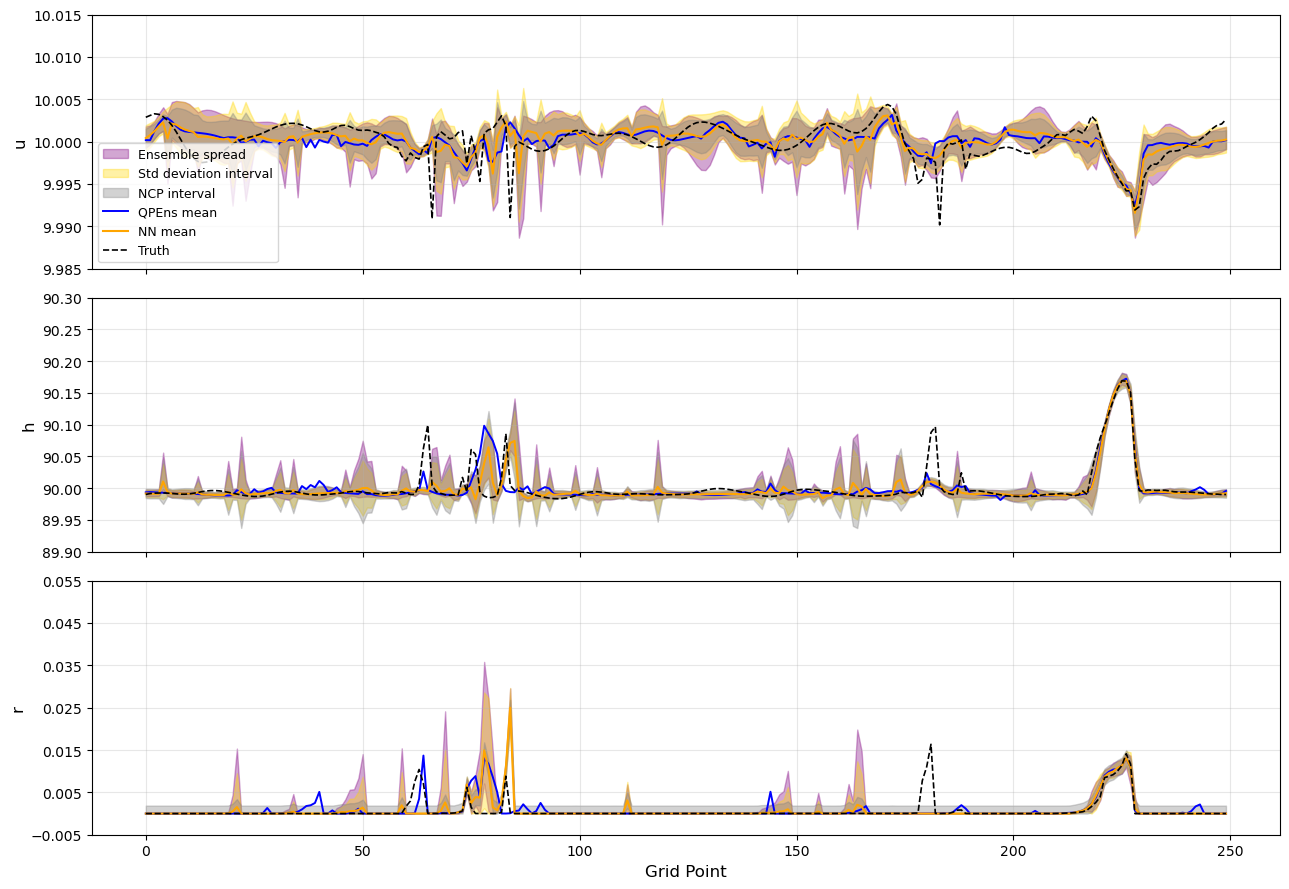

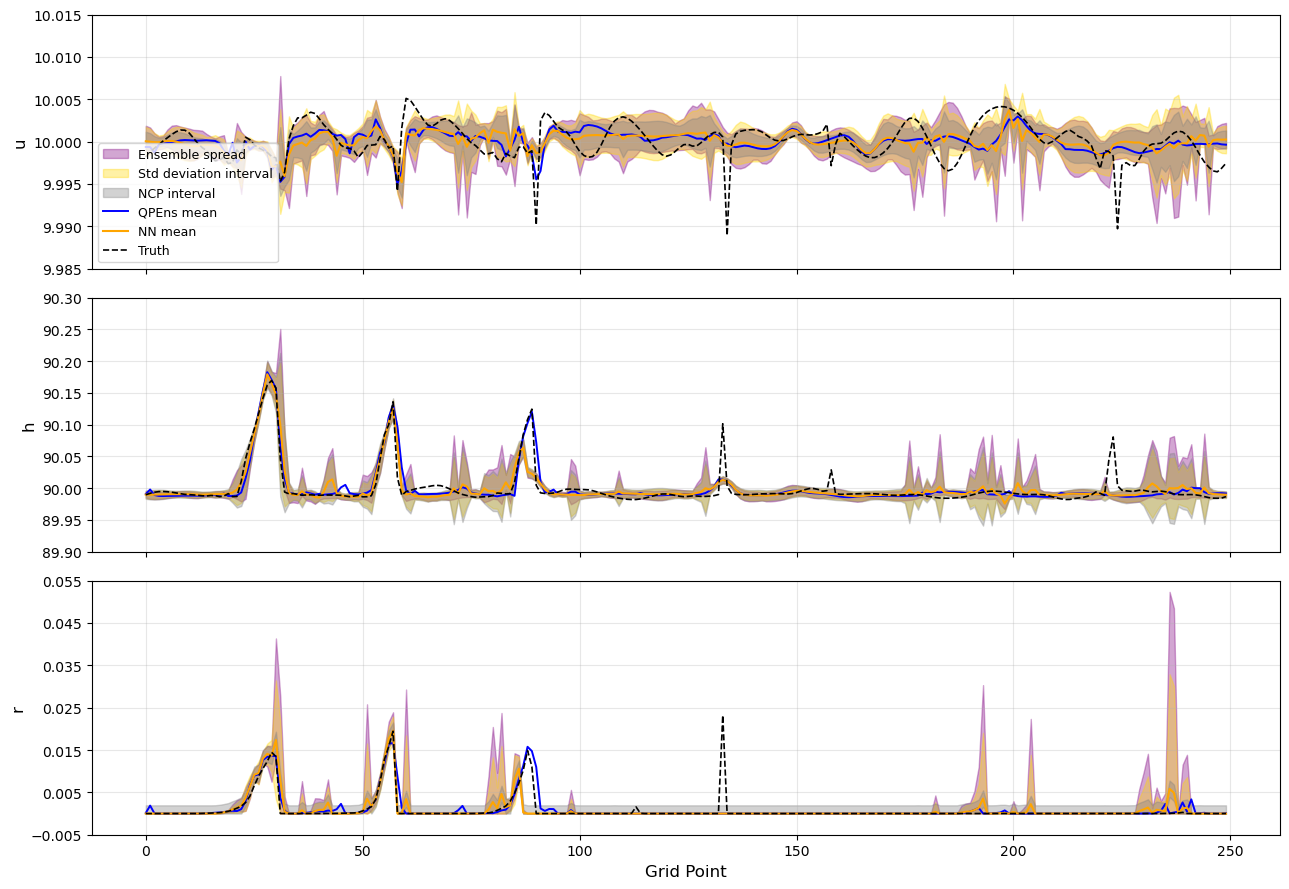

In [6]:
def load_ncp_ensemble(seed, t):
    path = os.path.join(base_path, str(seed))
    with open(os.path.join(path, 'NN_data.pkl'), 'rb') as f:
        nn = pickle.load(f)
    with open(os.path.join(path, 'QPEns_data.pkl'), 'rb') as f:
        qpens = pickle.load(f)
    nn_arr    = np.asarray(nn['analysis'][t])
    qpens_arr = np.asarray(qpens['analysis'][t])
    nn_ens    = {v: nn_arr[sl, :].mean(axis=1)       for v, sl in slices.items()}  
    qpens_ens = {v: qpens_arr[sl, :].mean(axis=1)    for v, sl in slices.items()}  
    nn_std    = {v: nn_arr[sl, :].std(axis=1, ddof=1) for v, sl in slices.items()}  
    return nn_ens, qpens_ens, nn_std

def load_ncp_plot_data(seed, t):
    path = os.path.join(base_path, str(seed))
    with open(os.path.join(path, 'NN_data.pkl'), 'rb') as f:
        nn = pickle.load(f)
    with open(os.path.join(path, 'QPEns_data.pkl'), 'rb') as f:
        qpens = pickle.load(f)
    with open(os.path.join(path, 'truth_data.pkl'), 'rb') as f:
        truth = pickle.load(f)
    nn_arr    = np.asarray(nn['analysis'][t])
    qpens_arr = np.asarray(qpens['analysis'][t])
    truth_arr = np.asarray(truth[t]).squeeze()
    mean_all  = nn_arr.mean(axis=1)
    std_all   = nn_arr.std(axis=1, ddof=1)
    return {
        'nn_mean' : {v: mean_all[sl]                    for v, sl in slices.items()},
        'nn_std'  : {v: std_all[sl]                     for v, sl in slices.items()},
        'nn_lo'   : {v: (mean_all - Z_90*std_all)[sl]   for v, sl in slices.items()},
        'nn_hi'   : {v: (mean_all + Z_90*std_all)[sl]   for v, sl in slices.items()},
        'nn_min'  : {v: nn_arr[sl, :].min(axis=1)       for v, sl in slices.items()},
        'nn_max'  : {v: nn_arr[sl, :].max(axis=1)       for v, sl in slices.items()},
        'q_mean'  : {v: qpens_arr[sl, :].mean(axis=1)   for v, sl in slices.items()},
        'truth'   : {v: truth_arr[sl]                   for v, sl in slices.items()},
    }

def compute_ncp_threshold(t):
    scores_cal = {v: [] for v in VARS}
    for seed in calib_seeds:
        nn_ens, qpens_ens, nn_std = load_ncp_ensemble(seed, t)
        for v in VARS:
            nn_v  = nn_ens[v]
            qp_v  = qpens_ens[v]
            res   = np.abs(qp_v - nn_v)
            if v in ('u', 'h'):
                std_stack = np.maximum(nn_std[v], 1e-8)  
                scores_cal[v].append((res / std_stack).ravel())
            else:
                scores_cal[v].append(res.ravel())
    thresholds = {}
    for v in VARS:
        s     = np.concatenate(scores_cal[v])
        N     = s.size
        qprob = float(np.ceil((N + 1) * (1 - alpha)) / N)
        thresholds[v] = float(np.quantile(s, min(qprob, 1.0), method="inverted_cdf"))
    return thresholds

def plot_ncp_vs_traditional(t):
    thresholds = compute_ncp_threshold(t)
    s = load_ncp_plot_data(test_seed, t)
    x = np.arange(nx)
    fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
    for i, v in enumerate(VARS):
        ax         = axes[i]
        nn_line    = s['nn_mean'][v]
        qpens_line = s['q_mean'][v]
        truth_line = s['truth'][v]

        if v in ('u', 'h'):
            nn_std_safe = np.maximum(s['nn_std'][v], 1e-8) 
            ncp_band = thresholds[v] * nn_std_safe
        else:
            ncp_band = np.full(nx, thresholds[v])

        ncp_lo = nn_line - ncp_band
        ncp_hi = nn_line + ncp_band
        std_lo = s['nn_lo'][v]
        std_hi = s['nn_hi'][v]
        min_l  = s['nn_min'][v]
        max_l  = s['nn_max'][v]

        if v == 'r':
            ncp_lo = np.maximum(ncp_lo, 0)
            ncp_hi = np.maximum(ncp_hi, 0)
            std_lo = np.maximum(std_lo, 0)
            std_hi = np.maximum(std_hi, 0)
            min_l  = np.maximum(min_l,  0)
            max_l  = np.maximum(max_l,  0)

        ax.fill_between(x, min_l,  max_l,  color='purple', alpha=0.35, label='Ensemble spread')
        ax.fill_between(x, std_lo, std_hi, color='gold',   alpha=0.35, label='Std deviation interval')
        ax.fill_between(x, ncp_lo, ncp_hi, color='gray',   alpha=0.35, label='NCP interval')
        ax.plot(x, qpens_line, color='blue',   linewidth=1.4, label='QPEns mean')
        ax.plot(x, nn_line,    color='orange', linewidth=1.5, label='NN mean')
        ax.plot(x, truth_line, color='black',  linewidth=1.2, linestyle='--', label='Truth')
        ax.set_ylabel(v, fontsize=12)
        ax.set_ylim(YLIMS[v])
        ax.set_yticks(np.arange(YLIMS[v][0], YLIMS[v][1]+0.5*YSTEP[v], YSTEP[v]))
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(loc='lower left', fontsize=9, frameon=True)

    axes[-1].set_xlabel("Grid Point", fontsize=12)
    plt.tight_layout()
    plt.show()

for t in timesteps:
    plot_ncp_vs_traditional(t)

# CQR vs Traditional Uncertainty Methods

In [7]:
base_path     = r"C:\Users\MGA5500\Desktop\PROJECT\WW\Data"       
base_path_cqr = r"C:\Users\MGA5500\Desktop\PROJECT\WW\MSW codes Reimp" 
calib_seeds   = list(range(60, 69))
test_seed     = 69
timesteps     = [25, 160]
nx            = 250
alpha         = 0.10
Z_90          = 1.645
slices        = {'u': slice(0, nx), 'h': slice(nx, 2*nx), 'r': slice(2*nx, 3*nx)}
VARS          = ['u', 'h', 'r']
YLIMS         = {'u': (9.985, 10.015), 'h': (89.90, 90.30), 'r': (-0.005, 0.055)}
YSTEP         = {'u': 0.005, 'h': 0.05, 'r': 0.01}

t=25  deltas: {'u': 0.0008680149099955514, 'h': 0.006810093796744354, 'r': 0.0009501835944299322}


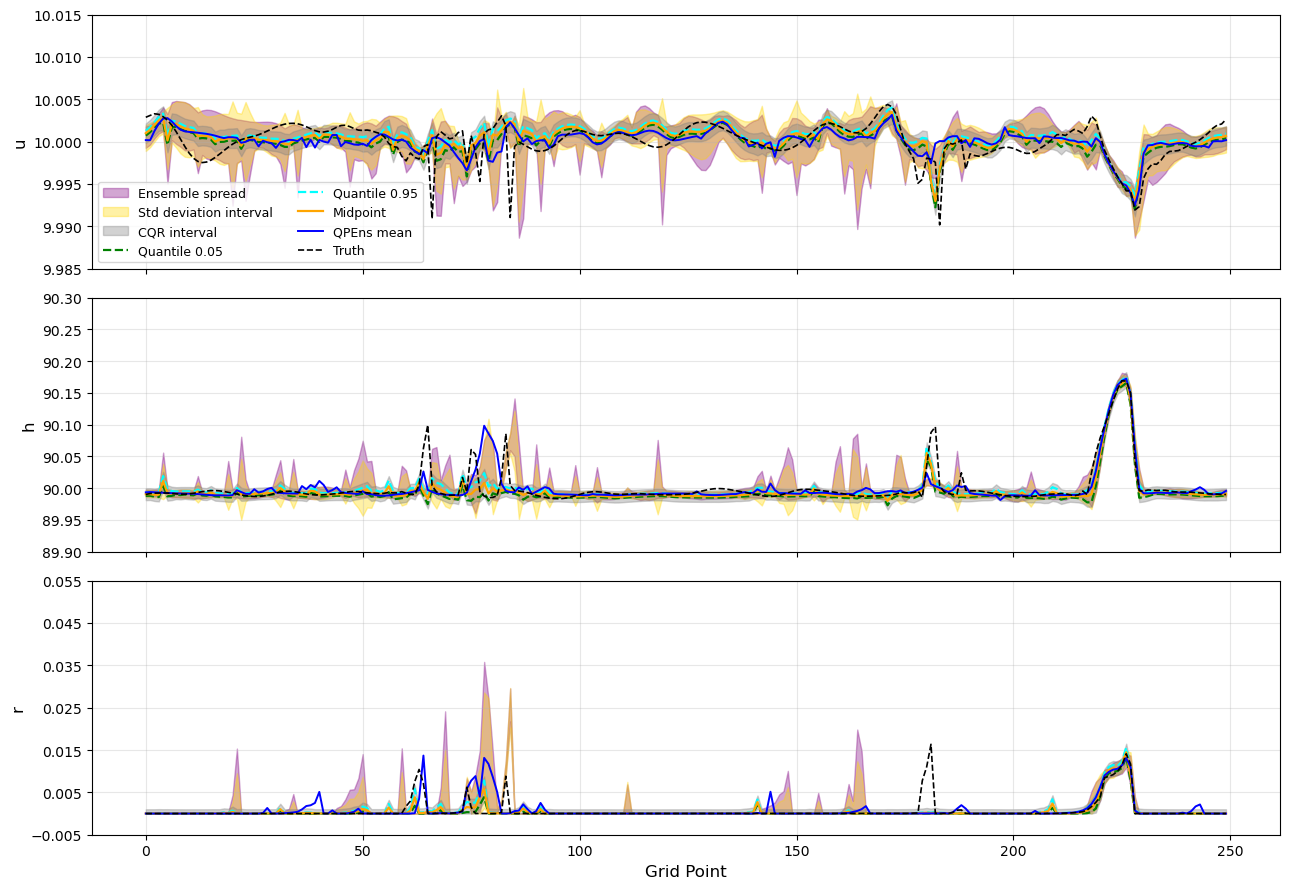

t=160  deltas: {'u': 0.0008949175223289529, 'h': 0.006485637941494815, 'r': 0.0012449252733768284}


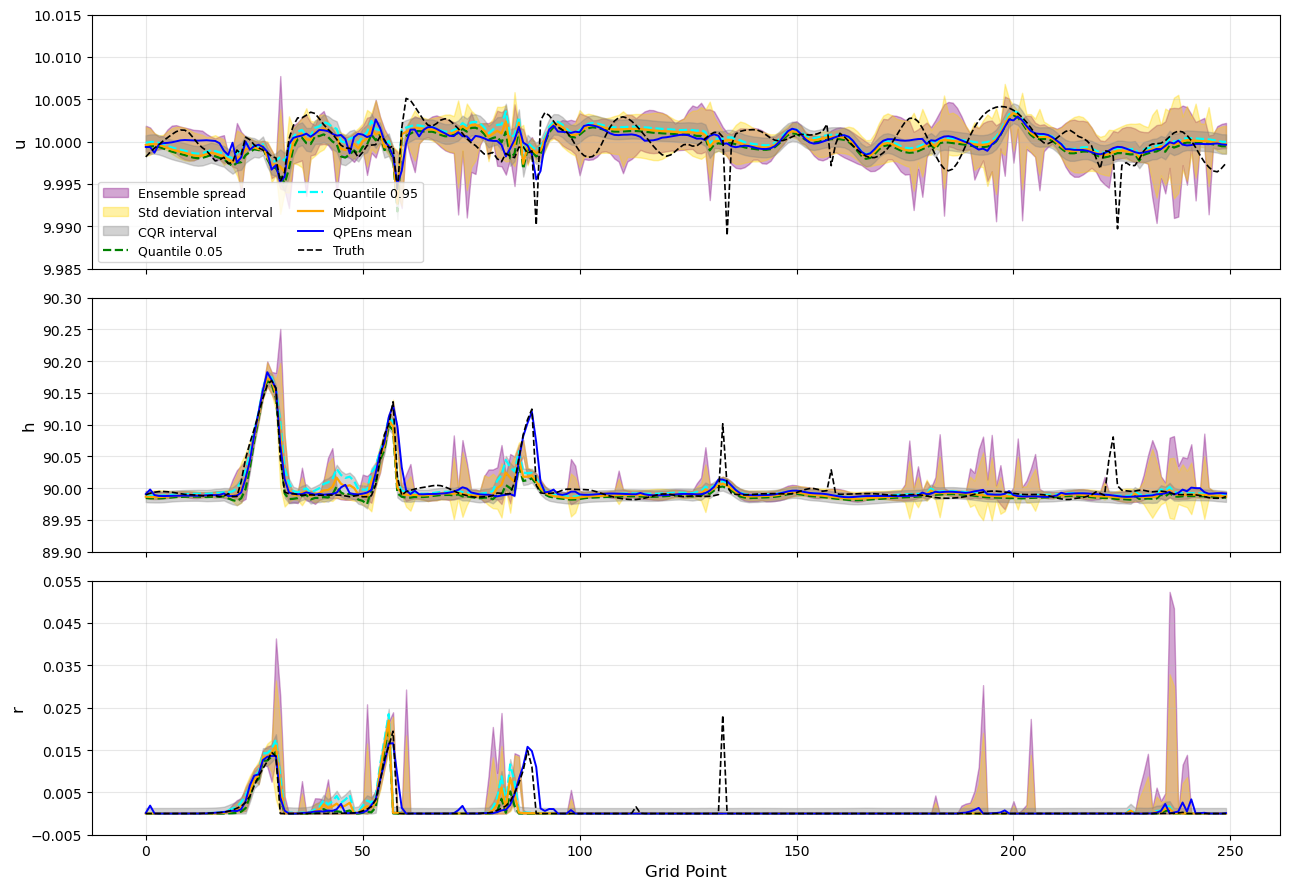

In [8]:
def load_cqr_stats(seed, t):
    path = os.path.join(base_path_cqr, str(seed))
    with open(os.path.join(path, 'NN_data.pkl'), 'rb') as f:
        nn = pickle.load(f)
    with open(os.path.join(path, 'QPEns_data.pkl'), 'rb') as f:
        qpens = pickle.load(f)
    lo_all    = np.asarray(nn['lower'][t]).mean(axis=1)    
    hi_all    = np.asarray(nn['upper'][t]).mean(axis=1)    
    qpens_arr = np.asarray(qpens['analysis'][t])
    qpens_mean = qpens_arr.mean(axis=1)                   
    return {
        'lo'     : {v: lo_all[sl]       for v, sl in slices.items()}, 
        'hi'     : {v: hi_all[sl]       for v, sl in slices.items()},  
        'mid'    : {v: 0.5*(lo_all+hi_all)[sl] for v, sl in slices.items()}, 
        'q_mean' : {v: qpens_mean[sl]   for v, sl in slices.items()},  
    }

def load_main_stats(seed, t):
    path = os.path.join(base_path, str(seed))
    with open(os.path.join(path, 'NN_data.pkl'), 'rb') as f:
        nn = pickle.load(f)
    with open(os.path.join(path, 'truth_data.pkl'), 'rb') as f:
        truth = pickle.load(f)
    nn_arr    = np.asarray(nn['analysis'][t])
    truth_arr = np.asarray(truth[t]).squeeze()
    mean_all  = nn_arr.mean(axis=1)
    std_all   = nn_arr.std(axis=1, ddof=1)
    return {
        'nn_lo'  : {v: (mean_all - Z_90*std_all)[sl] for v, sl in slices.items()},
        'nn_hi'  : {v: (mean_all + Z_90*std_all)[sl] for v, sl in slices.items()},
        'nn_min' : {v: nn_arr[sl, :].min(axis=1)     for v, sl in slices.items()},
        'nn_max' : {v: nn_arr[sl, :].max(axis=1)     for v, sl in slices.items()},
        'truth'  : {v: truth_arr[sl]                 for v, sl in slices.items()},
    }

def compute_cqr_delta(t):
    pooled = {v: [] for v in VARS}
    for seed in calib_seeds:
        try:
            cs = load_cqr_stats(seed, t)
        except Exception as e:
            print(f"seed={seed}, t={t}: {e}")
            continue
        for v in VARS:
            lo_v   = cs['lo'][v]      
            hi_v   = cs['hi'][v]      
            y_v    = cs['q_mean'][v]  
            scores = np.maximum(np.maximum(lo_v - y_v, y_v - hi_v), 0.0)  
            pooled[v].append(scores.ravel())
    deltas = {}
    for v in VARS:
        if not pooled[v]:
            deltas[v] = 0.0
            continue
        s_all     = np.concatenate(pooled[v])
        N         = s_all.size
        qprob     = float(np.ceil((N + 1) * (1 - alpha)) / N)
        deltas[v] = float(np.quantile(s_all, min(qprob, 1.0), method="inverted_cdf"))
    return deltas

def plot_cqr_vs_traditional(t):
    cs     = load_cqr_stats(test_seed, t)
    ms     = load_main_stats(test_seed, t)
    deltas = compute_cqr_delta(t)
    x = np.arange(nx)
    fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
    for i, v in enumerate(VARS):
        ax     = axes[i]
        d      = deltas[v]
        lo_raw = cs['lo'][v]
        hi_raw = cs['hi'][v]
        mid    = cs['mid'][v]
        lo_c   = lo_raw - d
        hi_c   = hi_raw + d
        std_lo = ms['nn_lo'][v]
        std_hi = ms['nn_hi'][v]
        min_l  = ms['nn_min'][v]
        max_l  = ms['nn_max'][v]

        if v == 'r':
            lo_raw = np.maximum(lo_raw, 0)
            hi_raw = np.maximum(hi_raw, 0)
            mid    = np.maximum(mid,    0)
            lo_c   = np.maximum(lo_c,   0)
            hi_c   = np.maximum(hi_c,   0)
            std_lo = np.maximum(std_lo, 0)
            std_hi = np.maximum(std_hi, 0)
            min_l  = np.maximum(min_l,  0)
            max_l  = np.maximum(max_l,  0)

        ax.fill_between(x, min_l,  max_l,  color='purple', alpha=0.35, label='Ensemble spread')
        ax.fill_between(x, std_lo, std_hi, color='gold',   alpha=0.35, label='Std deviation interval')
        ax.fill_between(x, lo_c,   hi_c,   color='gray',   alpha=0.35, label='CQR interval')
        ax.plot(x, lo_raw,          color='green',  linestyle='--', linewidth=1.6, label=f'Quantile {tau_lo:.2f}')
        ax.plot(x, hi_raw,          color='cyan',   linestyle='--', linewidth=1.6, label=f'Quantile {tau_hi:.2f}')
        ax.plot(x, mid,             color='orange', linewidth=1.6,                 label='Midpoint')
        ax.plot(x, cs['q_mean'][v], color='blue',   linewidth=1.4,                 label='QPEns mean')
        ax.plot(x, ms['truth'][v],  color='black',  linewidth=1.2, linestyle='--', label='Truth')
        ax.set_ylabel(v, fontsize=12)
        ax.set_ylim(YLIMS[v])
        ax.set_yticks(np.arange(YLIMS[v][0], YLIMS[v][1]+0.5*YSTEP[v], YSTEP[v]))
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(loc='lower left', ncols=2, fontsize=9, frameon=True)

    axes[-1].set_xlabel("Grid Point", fontsize=12)
    plt.tight_layout()
    plt.show()

for t in timesteps:
    deltas = compute_cqr_delta(t)
    print(f"t={t}  deltas: {deltas}")
    plot_cqr_vs_traditional(t)